In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import colorsys
from pathlib import Path
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import mannwhitneyu, kruskal
from matplotlib.gridspec import GridSpec
from matplotlib.colors import to_hex
from PIL import ImageColor

CONDITION_COLORS = {"2.4 fibroblasts": "red", "1.2 fibroblasts": "dodgerblue"}

In [ ]:
def create_n_valued_palette(base_colour, n=5):
    """Create n shades of a base colour (name or hex) for per-image lines."""
    r, g, b = [v / 255 for v in ImageColor.getcolor(base_colour, "RGB")]
    h, lightness, s = colorsys.rgb_to_hls(r, g, b)
    palette = []
    for adj in np.linspace(0.5, 1.4, n):
        rgb = colorsys.hls_to_rgb(h, min(max(lightness * adj, 0), 1), s)
        palette.append(to_hex(rgb))
    return palette

In [ ]:
def combine_outputs(root_dir):
    """Find all CSVs under root_dir and concatenate into analysis and branch DataFrames."""
    csv_files = list(root_dir.rglob("*.csv"))
    if not csv_files:
        print("No CSV files found.")
        return None, None
    analysis_frames, branch_frames = [], []
    for f in csv_files:
        try:
            df = pd.read_csv(f)
            df["source_file"], df["source_folder"] = str(f), str(f.parent)
            if "analysis" in str(f): analysis_frames.append(df)
            elif "branch" in str(f): branch_frames.append(df)
            else: print(f"Found extra uncategorised csv {f}")
        except Exception as e:
            print(f"Failed to read {f}: {e}")
    combined_analysis = pd.concat(analysis_frames, ignore_index=True, sort=False) if analysis_frames else None
    combined_branches = pd.concat(branch_frames, ignore_index=True, sort=False) if branch_frames else None
    if combined_analysis is not None:
        combined_analysis.to_csv(root_dir / "combined_analysis_metrics.csv", index=False)
    else:
        print("No analysis metric files could be read successfully.")
    if combined_branches is not None:
        combined_branches.to_csv(root_dir / "combined_branch_metrics.csv", index=False)
    else:
        print("No branch metric files could be read successfully.")
    print(f"Total files combined: {len(analysis_frames)} analysis, {len(branch_frames)} branch")
    return combined_analysis, combined_branches

In [ ]:
############################# UPDATE THIS FOR YOUR EXPERIMENT #####################
def find_condition(row):
    """Map image_name to experiment condition based on substring matching."""
    name = str(row["image_name"]).lower()
    if "1.2fb" in name: return "1.2 fibroblasts"
    elif "2.4fb" in name: return "2.4 fibroblasts"
    return "NA"

In [ ]:
def plot_experiment_comparisons(df, metrics, xorder, plot_title, save_dir, save_type="png"):
    """Strip + box plot grid for each metric, coloured by experiment condition."""
    fig, axes = plt.subplots(ncols=len(metrics), figsize=(4 * len(metrics), 5))
    for i, metric in enumerate(metrics):
        sns.stripplot(data=df, x="experiment", y=metric, ax=axes[i], zorder=100,
                      hue="experiment", palette=CONDITION_COLORS, order=xorder, legend=False)
        sns.boxplot(data=df, x="experiment", y=metric, ax=axes[i], fill=False, color="#000000", order=xorder)
    plt.tight_layout()
    save_path = Path(save_dir) / f"{plot_title}.{save_type}"
    print(save_path)
    plt.savefig(save_path)

In [ ]:
def pca_plots(analysis_df, save_dir=None):
    """PCA scatter, volcano/importance-significance plot, and significant-features bar chart."""
    df = analysis_df[analysis_df["experiment"] != "NA"].copy()
    if len(df) == 0:
        print("No valid experiment labels found (all are 'NA').")
        return []

    metadata_cols = ["experiment", "image_name", "source_file", "image_index",
                     "chip_volume_um3", "convex_hull_volume_um3", "vessel_volume_um3", "source_folder"]
    features = df.drop(columns=[c for c in metadata_cols if c in df.columns])
    features = features.select_dtypes(include=[np.number]).dropna(axis=1, how="all")
    valid_rows = features.notna().all(axis=1)
    features, labels = features.loc[valid_rows], df.loc[valid_rows, "experiment"]

    conditions = [c for c in CONDITION_COLORS if c in labels.unique()]
    is_binary = len(conditions) == 2
    if len(conditions) < 2:
        print(f"Need at least 2 conditions for PCA, found: {conditions}")
        return features.columns.tolist()[:5]

    scaled = StandardScaler().fit_transform(features)
    pca = PCA(n_components=2)
    scores = pca.fit_transform(scaled)
    loadings, explained_var = pca.components_, pca.explained_variance_ratio_

    if is_binary:
        importance = loadings[0] * explained_var[0] + loadings[1] * explained_var[1]
        mean_pc1 = {c: scores[labels.values == c, 0].mean() for c in conditions}
        pos_class, neg_class = max(mean_pc1, key=mean_pc1.get), min(mean_pc1, key=mean_pc1.get)
        feature_importance = pd.Series(importance, index=features.columns).sort_values(key=abs, ascending=False)
    else:
        weighted = loadings * explained_var[:, None]
        importance = np.sqrt((weighted ** 2).sum(axis=0))
        feature_importance = pd.Series(importance, index=features.columns).sort_values(ascending=False)
        group_means = pd.DataFrame({c: features.loc[labels == c].mean() for c in conditions})
        deviations = group_means.subtract(features.mean(), axis=0).abs()
        dominant_class = deviations.idxmax(axis=1)

    # Statistical significance
    pvalues = []
    for col in features.columns:
        groups = [features.loc[labels == c, col].dropna() for c in conditions]
        if any(len(g) == 0 for g in groups): pvalues.append(1.0)
        elif is_binary: pvalues.append(mannwhitneyu(groups[0], groups[1], alternative="two-sided")[1])
        else: pvalues.append(kruskal(*groups)[1])

    pvalues = np.array(pvalues)
    neg_log_pvalues = -np.log10(np.clip(pvalues, 1e-300, None))
    significance_line = -np.log10(0.05)
    importance_values = feature_importance.reindex(features.columns).values
    significant_mask = pvalues < 0.05
    significant_features = feature_importance[significant_mask[
        feature_importance.index.map(lambda f: list(features.columns).index(f))]]

    # --- Plots ---
    fig = plt.figure(figsize=(20, 6), constrained_layout=True)
    gs = GridSpec(1, 3, figure=fig, width_ratios=[1, 1, 1.4])
    ax_pca, ax_volcano, ax_bar = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])

    # 1. PCA scatter
    for name in conditions:
        mask = labels == name
        ax_pca.scatter(scores[mask.values, 0], scores[mask.values, 1], c=CONDITION_COLORS[name],
                       label=name.capitalize(), s=80, edgecolors="k", linewidths=0.4, alpha=0.8)
    ax_pca.set_xlabel(f"PC1 ({explained_var[0]:.1%} var.)")
    ax_pca.set_ylabel(f"PC2 ({explained_var[1]:.1%} var.)")
    ax_pca.set_title("PCA – first two components")
    ax_pca.legend()

    # 2. Importance vs significance
    if is_binary:
        sig_pos = (neg_log_pvalues >= significance_line) & (importance_values > 0)
        sig_neg = (neg_log_pvalues >= significance_line) & (importance_values < 0)
        not_sig = neg_log_pvalues < significance_line
        ax_volcano.scatter(importance_values[not_sig], neg_log_pvalues[not_sig],
                           c="grey", alpha=0.5, s=40, label="Not significant")
        ax_volcano.scatter(importance_values[sig_pos], neg_log_pvalues[sig_pos], c=CONDITION_COLORS[pos_class],
                           alpha=0.8, s=60, label=f"Significant → {pos_class}")
        ax_volcano.scatter(importance_values[sig_neg], neg_log_pvalues[sig_neg], c=CONDITION_COLORS[neg_class],
                           alpha=0.8, s=60, label=f"Significant → {neg_class}")
        ax_volcano.axvline(0, color="grey", linewidth=0.5)
        ax_volcano.set_xlabel(f"PCA loading importance (+ → {pos_class}, − → {neg_class})")
        ax_volcano.set_title("Volcano plot – PCA loading vs significance")
    else:
        sig_mask = neg_log_pvalues >= significance_line
        ax_volcano.scatter(importance_values[~sig_mask], neg_log_pvalues[~sig_mask],
                           c="grey", alpha=0.5, s=40, label="Not significant")
        for name in conditions:
            cls_mask = sig_mask & (dominant_class.reindex(features.columns) == name).values
            if cls_mask.any():
                ax_volcano.scatter(importance_values[cls_mask], neg_log_pvalues[cls_mask], c=CONDITION_COLORS[name],
                                   alpha=0.8, s=60, label=f"Sig. dominant → {name}")
        ax_volcano.set_xlabel("PCA loading importance (variance-weighted magnitude)")
        ax_volcano.set_title("Importance vs significance (Kruskal-Wallis)")

    ax_volcano.axhline(significance_line, color="grey", linestyle="--", linewidth=0.8, label="p = 0.05")
    top_indices = np.argsort(neg_log_pvalues * np.abs(importance_values))[-5:]
    for idx in top_indices:
        ax_volcano.annotate(features.columns[idx], (importance_values[idx], neg_log_pvalues[idx]),
                            fontsize=7, ha="center", va="bottom", textcoords="offset points", xytext=(0, 5))
    ax_volcano.set_ylabel("$-\\log_{10}$(p-value)")
    ax_volcano.legend(fontsize=8)

    # 3. Top feature importances bar chart
    top = feature_importance.head(10)
    if is_binary:
        colors = [CONDITION_COLORS[pos_class] if v > 0 else CONDITION_COLORS[neg_class] for v in top]
        ax_bar.set_xlabel(f"Loading importance (+ → {pos_class}, − → {neg_class})")
    else:
        colors = [CONDITION_COLORS.get(dominant_class[feat], "grey") for feat in top.index]
        ax_bar.set_xlabel("Loading importance (coloured by dominant class)")
    ax_bar.barh(top.index[::-1], top.values[::-1], color=colors[::-1])
    ax_bar.set_title("Top 10 discriminating features")
    ax_bar.axvline(0, color="grey", linewidth=0.8)
    ax_bar.tick_params(axis="y", labelsize=9)

    if save_dir is not None: fig.savefig(Path(save_dir) / "pca_plots.png", dpi=150)
    plt.show()

    print(f"Significant features: {len(significant_features)} / {len(features.columns)}")
    if len(significant_features) == 0:
        fallback = feature_importance.head(5).index.to_list()
        print(f"No significant features found — returning top 5 by importance: {fallback}")
        return fallback
    return significant_features.index.to_list()

In [ ]:
root_dir = Path(r"Z:\Bel\Chiara_Vascumap\To_run")
output_dir = root_dir.parent / f"{root_dir.name}_output_data"
output_dir.mkdir(parents=True, exist_ok=True)
combined_analysis_metrics, combined_branch_metrics = combine_outputs(root_dir)

Total files combined: 20 analysis files and 99074 branch files


In [18]:
combined_analysis_metrics

,image_name,source_file,image_index,chip_volume_um3,convex_hull_volume_um3,vessel_volume_um3,vessel_volume_fraction,total_vessel_length_um,vessel_length_per_chip_volume_um_inverse2,sprouts_per_vessel_length_um_inverse,...,median_junction_dist_nearest_junction_um,p90_minus_p10_junction_dist_nearest_junction_um,median_sprout_dist_nearest_endpoint_um,p90_minus_p10_sprout_dist_nearest_endpoint_um,average_vessel_volume_um3,median_internal_pore_area_um2,p90_minus_p10_internal_pore_area_um2,sprouts_per_chip_volume_um_inverse3,junctions_per_chip_volume_um_inverse3,source_folder
0,20260414_seeding250326_fixed_for_vascumap_1.2F...,Z:\Bel\Chiara_Vascumap\To_run\combined_analysi...,1,2.189118e+09,2.145565e+09,1.098402e+09,0.511940,499288.046368,0.000233,0.000687,...,33.287156,80.884956,403.237373,454.321444,526081.027452,2048.0,16766.4,1.598646e-07,0.000001,Z:\Bel\Chiara_Vascumap\To_run
1,20260414_seeding250326_fixed_for_vascumap_1.2F...,Z:\Bel\Chiara_Vascumap\To_run\combined_analysi...,3,2.304127e+09,2.254313e+09,9.915519e+08,0.439847,696708.145571,0.000309,0.000403,...,29.998542,67.648878,421.297652,452.991141,426493.960550,2120.0,13100.0,1.246499e-07,0.000002,Z:\Bel\Chiara_Vascumap\To_run
2,20260414_seeding250326_fixed_for_vascumap_1.2F...,Z:\Bel\Chiara_Vascumap\To_run\combined_analysi...,5,1.988016e+09,1.938876e+09,7.560626e+08,0.389949,405030.107774,0.000209,0.000783,...,34.078373,71.113678,355.784239,390.369528,261745.687992,1844.0,13052.0,1.634967e-07,0.000001,Z:\Bel\Chiara_Vascumap\To_run
3,20260414_seeding250326_fixed_for_vascumap_1.2F...,Z:\Bel\Chiara_Vascumap\To_run\combined_analysi...,6,2.230736e+09,2.165816e+09,7.455308e+08,0.344226,521439.318057,0.000241,0.000535,...,31.170115,73.093290,416.236602,503.585218,291040.721454,3040.0,24182.0,1.288198e-07,0.000002,Z:\Bel\Chiara_Vascumap\To_run
4,20260414_seeding250326_fixed_for_vascumap_1.2F...,Z:\Bel\Chiara_Vascumap\To_run\combined_analysi...,7,2.285821e+09,2.241623e+09,1.012739e+09,0.451788,444563.892824,0.000198,0.000565,...,37.969318,82.654152,392.299910,513.969245,664962.697742,1448.0,9891.2,1.119725e-07,0.000001,Z:\Bel\Chiara_Vascumap\To_run
5,20260414_seeding250326_fixed_for_vascumap_2.4F...,Z:\Bel\Chiara_Vascumap\To_run\combined_analysi...,0,1.569937e+09,1.529738e+09,6.956755e+08,0.454768,476112.144492,0.000311,0.000664,...,29.249946,69.667221,384.910622,484.242880,250277.052168,3452.0,25345.2,2.065713e-07,0.000002,Z:\Bel\Chiara_Vascumap\To_run
6,20260414_seeding250326_fixed_for_vascumap_2.4F...,Z:\Bel\Chiara_Vascumap\To_run\combined_analysi...,1,2.308345e+09,2.262043e+09,1.071248e+09,0.473576,658891.524158,0.000291,0.000402,...,29.656854,67.547363,411.006154,473.083269,496098.489861,2072.0,13245.2,1.171507e-07,0.000002,Z:\Bel\Chiara_Vascumap\To_run
7,20260414_seeding250326_fixed_for_vascumap_2.4F...,Z:\Bel\Chiara_Vascumap\To_run\combined_analysi...,2,2.341243e+09,2.296479e+09,5.885645e+08,0.256290,432212.135080,0.000188,0.000812,...,31.499159,74.795773,371.753746,440.193267,208228.236865,2660.0,25195.6,1.528427e-07,0.000001,Z:\Bel\Chiara_Vascumap\To_run
8,20260414_seeding250326_fixed_for_vascumap_2.4F...,Z:\Bel\Chiara_Vascumap\To_run\combined_analysi...,3,1.985062e+09,1.941086e+09,8.680667e+08,0.447207,468184.460133,0.000241,0.000596,...,32.938827,83.936061,449.371038,539.803413,539019.582535,2588.0,18049.6,1.437340e-07,0.000001,Z:\Bel\Chiara_Vascumap\To_run
9,20260414_seeding250326_fixed_for_vascumap_2.4F...,Z:\Bel\Chiara_Vascumap\To_run\combined_analysi...,4,1.563272e+09,1.522807e+09,8.576488e+08,0.563203,407927.035494,0.000268,0.000664,...,33.513251,73.405227,387.915853,446.445503,370428.964552,1408.0,9308.0,1.779608e-07,0.000002,Z:\Bel\Chiara_Vascumap\To_run


In [25]:
combined_analysis_metrics["experiment"] = combined_analysis_metrics.apply(find_condition, axis=1)

In [ ]:
cols_to_drop = ["median_sprout_and_branch_median_cs_area_um2", "median_internal_pore_area_um2",
                "median_internal_pore_max_inscribed_radius_um", "p90_minus_p10_internal_pore_area_um2",
                "total_internal_pore_count", "p90_minus_p10_internal_pore_max_inscribed_radius_um",
                "internal_pore_area_fraction_in_filled_vascular_area"]
present = [c for c in cols_to_drop if c in combined_analysis_metrics.columns]
missing = [c for c in cols_to_drop if c not in combined_analysis_metrics.columns]
if missing: print(f"Columns not in data (skipped): {missing}")
combined_analysis_metrics_minimal = combined_analysis_metrics.drop(columns=present)

Columns not in data (skipped): ['median_internal_pore_max_inscribed_radius_um', 'total_internal_pore_count', 'p90_minus_p10_internal_pore_max_inscribed_radius_um', 'internal_pore_area_fraction_in_filled_vascular_area']


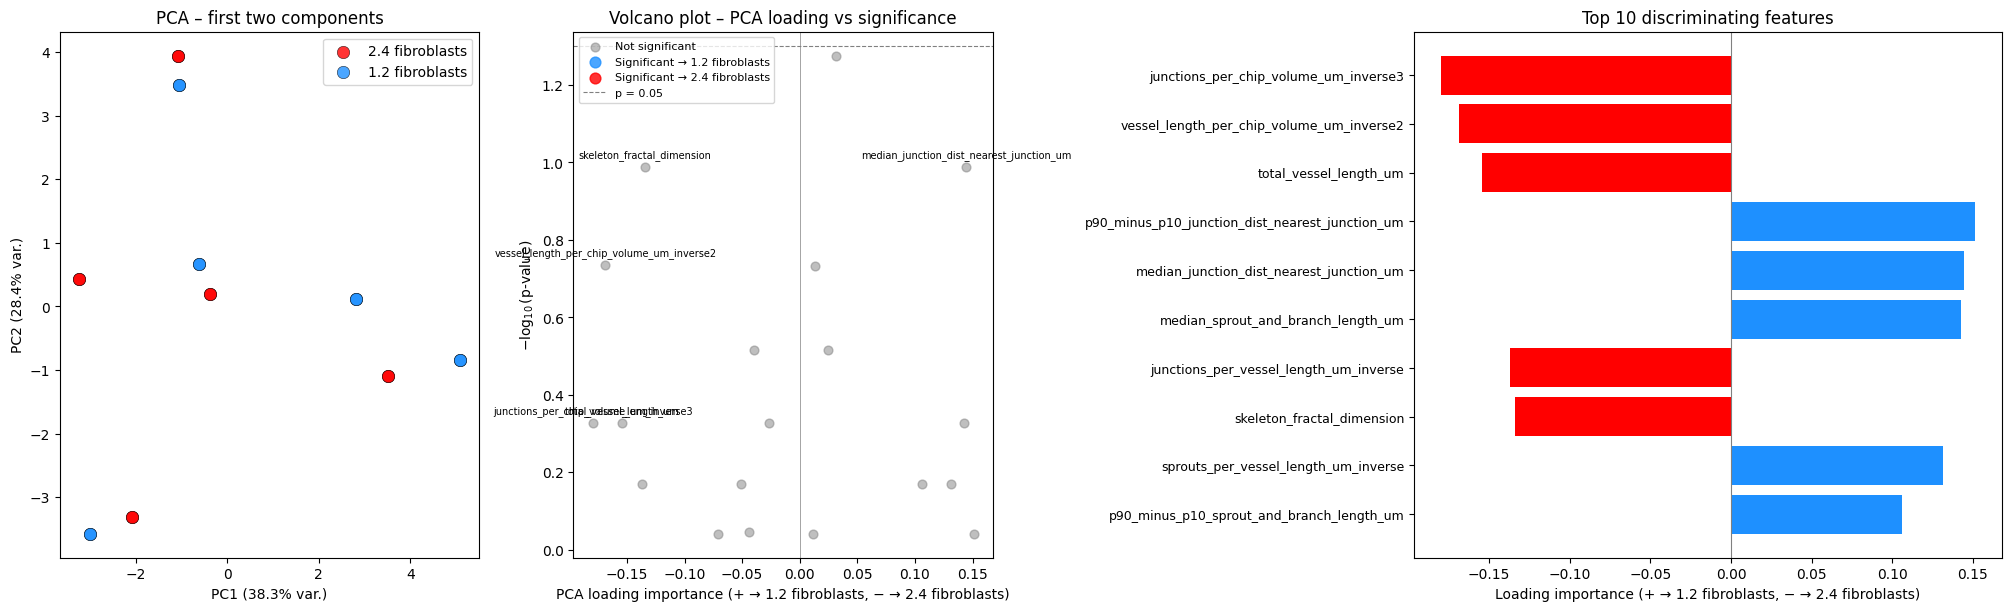

Significant features: 0 / 19
No significant features found — returning top 5 by importance: ['junctions_per_chip_volume_um_inverse3', 'vessel_length_per_chip_volume_um_inverse2', 'total_vessel_length_um', 'p90_minus_p10_junction_dist_nearest_junction_um', 'median_junction_dist_nearest_junction_um']


In [ ]:
significant_params = pca_plots(combined_analysis_metrics_minimal, save_dir=output_dir)

0 junctions_per_chip_volume_um_inverse3
1 vessel_length_per_chip_volume_um_inverse2
2 total_vessel_length_um
3 p90_minus_p10_junction_dist_nearest_junction_um
4 median_junction_dist_nearest_junction_um
Z:\Bel\Chiara_Vascumap\To_run_output_data\significant_changes.png


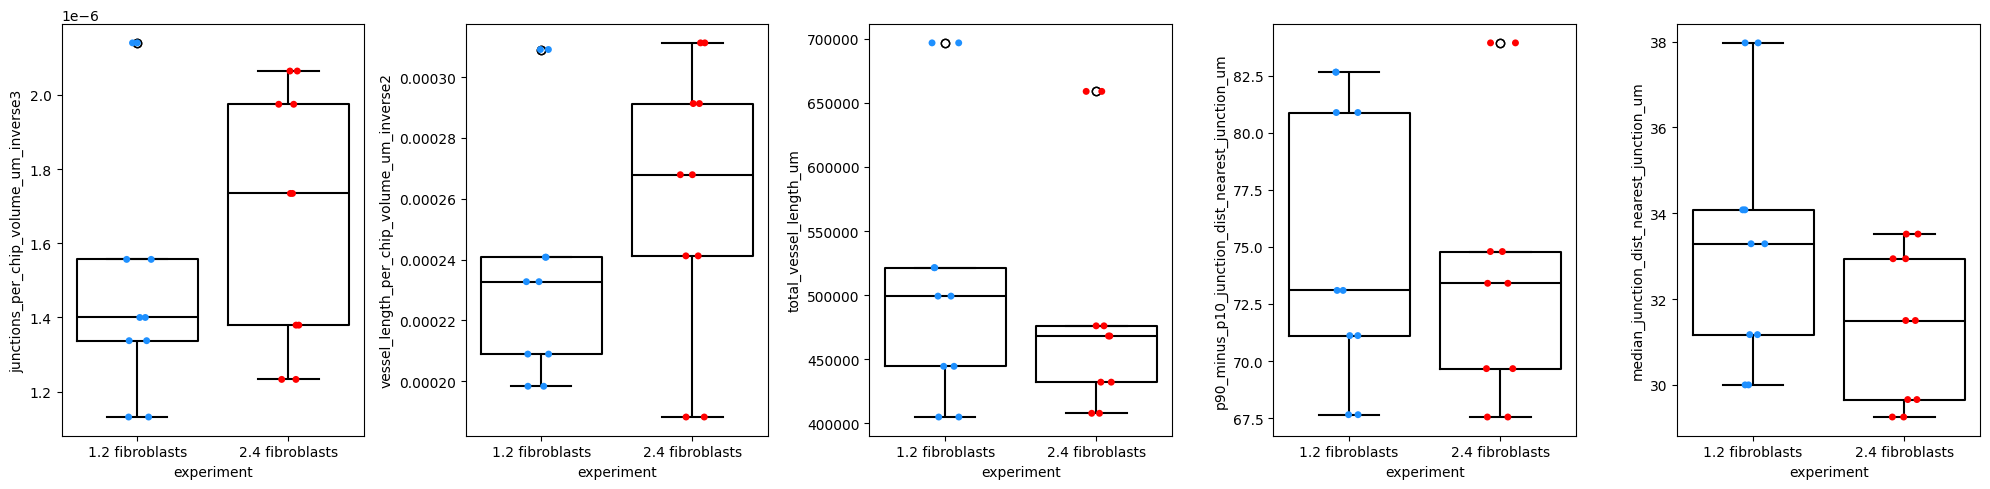

In [ ]:
plot_experiment_comparisons(combined_analysis_metrics, significant_params[:5],
                           list(CONDITION_COLORS.keys()), "significant_changes", output_dir)